# BiRefNet 배경 제거 & 블랙 마스킹

`final_images/` 폴더의 사람 이미지 전체를 BiRefNet 모델로 처리합니다.

- **배경**: 투명 (alpha = 0)
- **인물**: 검정 마스킹 (R=0, G=0, B=0, alpha = 255)
- **출력**: `final_images_masked/` 폴더에 PNG로 저장


In [16]:
# 필요 패키지 설치 (최초 1회)
import subprocess

subprocess.run(
    ["pip", "install", "transformers", "torch", "torchvision", "Pillow", "numpy"],
    check=True,
)

CompletedProcess(args=['pip', 'install', 'transformers', 'torch', 'torchvision', 'Pillow', 'numpy'], returncode=0)

In [17]:
import os
import glob
import numpy as np
import torch
from PIL import Image
from torchvision import transforms
from transformers import AutoModelForImageSegmentation

# ── 설정 ──────────────────────────────────────
INPUT_DIR = "../final_images"
OUTPUT_DIR = "../final_images_masked"
MODEL_SIZE = (1024, 1024)  # BiRefNet 권장 입력 해상도
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"장치: {DEVICE}")
print(f"입력: {INPUT_DIR}")
print(f"출력: {OUTPUT_DIR}")

장치: cpu
입력: ../final_images
출력: ../final_images_masked


In [18]:
# BiRefNet 모델 로드 (HuggingFace Hub: ZhengPeng7/BiRefNet)
print("BiRefNet 모델 로드 중...")
model = AutoModelForImageSegmentation.from_pretrained(
    "ZhengPeng7/BiRefNet",
    trust_remote_code=True,
)
model.to(DEVICE)
model.float()  # fp16 가중치 → float32 강제 변환 (CPU에서 Half 타입 불일치 방지)
model.eval()
print("모델 로드 완료")

BiRefNet 모델 로드 중...


Loading weights:   0%|          | 0/754 [00:00<?, ?it/s]

모델 로드 완료


In [19]:
# 전처리 변환 (BiRefNet 권장)
preprocess = transforms.Compose(
    [
        transforms.Resize(MODEL_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


def get_foreground_mask(image: Image.Image) -> np.ndarray:
    """
    BiRefNet으로 전경(사람) 마스크를 추출합니다.
    반환: (H, W) uint8 배열, 0~255 (255 = 전경)
    """
    orig_w, orig_h = image.size
    input_tensor = preprocess(image.convert("RGB")).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        preds = model(input_tensor)

    # BiRefNet은 마지막 pred를 사용 (sigmoid 적용)
    pred = preds[-1].sigmoid().squeeze().cpu().numpy()  # (1024, 1024), float32

    # 원본 해상도로 복원
    mask_img = Image.fromarray((pred * 255).astype(np.uint8)).resize(
        (orig_w, orig_h), Image.LANCZOS
    )
    return np.array(mask_img)


def apply_black_mask_transparent_bg(
    image: Image.Image, mask: np.ndarray
) -> Image.Image:
    """
    mask 값 기반으로:
      - 전경(사람): 검정 (R=0, G=0, B=0), alpha = mask 값 (불투명)
      - 배경       : R=0, G=0, B=0, alpha = 0 (완전 투명)
    """
    # 이진화: 전경 임계값 0.5
    binary = (mask > 127).astype(np.uint8)  # 1 = 전경, 0 = 배경

    h, w = binary.shape
    rgba = np.zeros((h, w, 4), dtype=np.uint8)  # 전체 투명으로 초기화
    # 전경 픽셀만 alpha = 255, RGB = 0 (검정)
    rgba[:, :, 3] = binary * 255

    return Image.fromarray(rgba, "RGBA")


print("헬퍼 함수 정의 완료")

헬퍼 함수 정의 완료


In [20]:
# final_images 전체 이미지 처리
image_paths = sorted(
    glob.glob(os.path.join(INPUT_DIR, "*.jpg"))
    + glob.glob(os.path.join(INPUT_DIR, "*.jpeg"))
    + glob.glob(os.path.join(INPUT_DIR, "*.png"))
)

print(f"처리할 이미지 수: {len(image_paths)}개\n")

for img_path in image_paths:
    fname = os.path.splitext(os.path.basename(img_path))[0]
    out_path = os.path.join(OUTPUT_DIR, f"{fname}.png")

    print(f"[처리 중] {os.path.basename(img_path)} → {os.path.basename(out_path)}")

    image = Image.open(img_path).convert("RGB")
    mask = get_foreground_mask(image)
    result = apply_black_mask_transparent_bg(image, mask)
    result.save(out_path, "PNG")

    print(f"         저장 완료: {out_path}")

print(f"\n완료! 총 {len(image_paths)}개 이미지 처리됨 → {OUTPUT_DIR}")

처리할 이미지 수: 11개

[처리 중] 1.jpg → 1.png
         저장 완료: ../final_images_masked\1.png
[처리 중] 10.jpg → 10.png
         저장 완료: ../final_images_masked\10.png
[처리 중] 11.jpg → 11.png
         저장 완료: ../final_images_masked\11.png
[처리 중] 2.jpg → 2.png
         저장 완료: ../final_images_masked\2.png
[처리 중] 3.jpg → 3.png
         저장 완료: ../final_images_masked\3.png
[처리 중] 4.jpg → 4.png
         저장 완료: ../final_images_masked\4.png
[처리 중] 5.jpg → 5.png
         저장 완료: ../final_images_masked\5.png
[처리 중] 6.jpg → 6.png
         저장 완료: ../final_images_masked\6.png
[처리 중] 7.jpg → 7.png
         저장 완료: ../final_images_masked\7.png
[처리 중] 8.jpg → 8.png
         저장 완료: ../final_images_masked\8.png
[처리 중] 9.jpg → 9.png
         저장 완료: ../final_images_masked\9.png

완료! 총 11개 이미지 처리됨 → ../final_images_masked


C:\Users\user\AppData\Local\Temp\ipykernel_5020\2622514610.py:20: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5020\2622514610.py:20: UserWarning: Glyph 47001 (\N{HANGUL SYLLABLE RAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5020\2622514610.py:20: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5020\2622514610.py:20: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5020\2622514610.py:20: UserWarning: Glyph 53433 (\N{HANGUL SYLLABLE KING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_5020\2622514610.py:20: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s

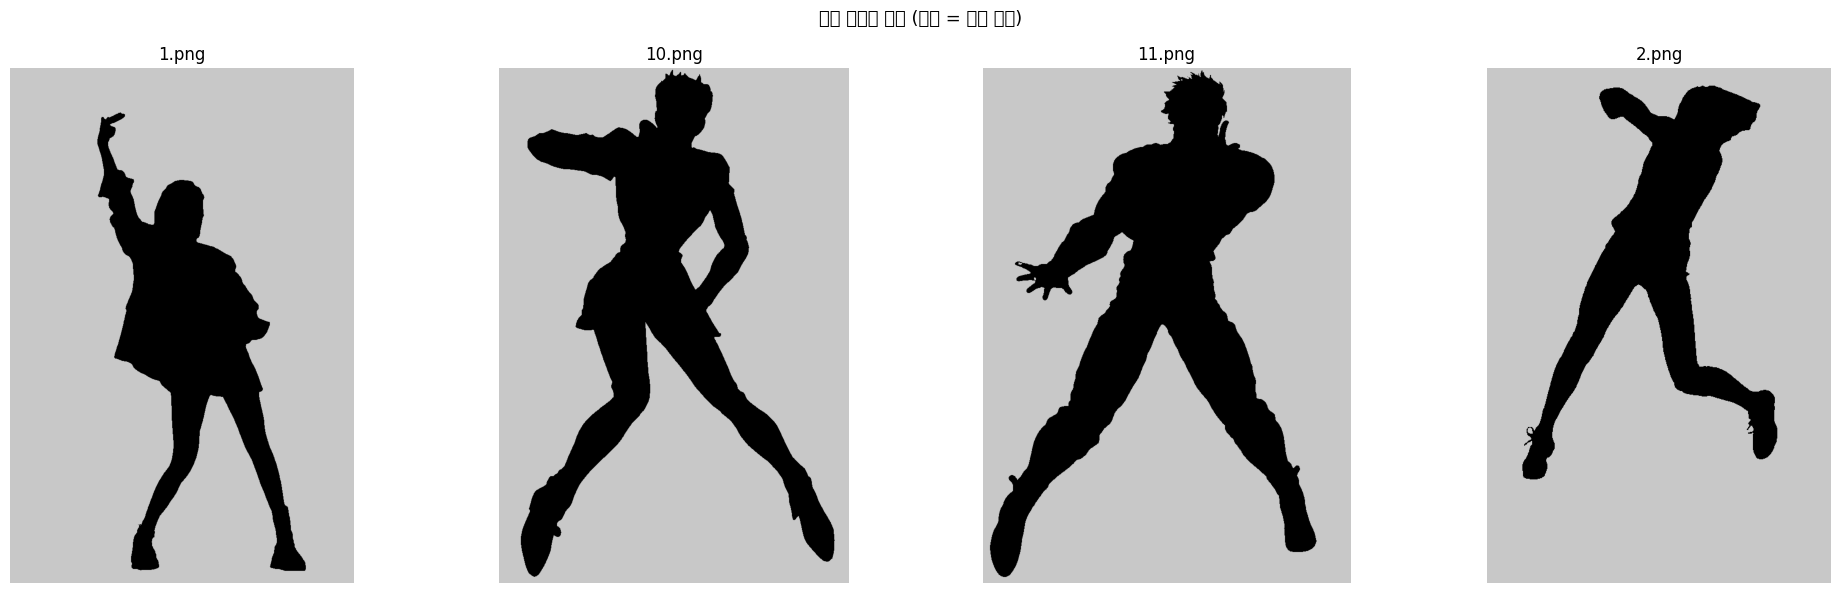

In [21]:
# 결과 미리보기 (처음 4장)
import matplotlib.pyplot as plt

result_paths = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.png")))[:4]

fig, axes = plt.subplots(1, len(result_paths), figsize=(5 * len(result_paths), 6))
if len(result_paths) == 1:
    axes = [axes]

for ax, path in zip(axes, result_paths):
    img = Image.open(path).convert("RGBA")
    # 투명 배경을 흰색으로 렌더링해서 미리보기
    bg = Image.new("RGBA", img.size, (200, 200, 200, 255))
    bg.paste(img, mask=img.split()[3])
    ax.imshow(bg)
    ax.set_title(os.path.basename(path))
    ax.axis("off")

plt.suptitle("블랙 마스킹 결과 (회색 = 투명 배경)", fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# final_images_masked 전체 이미지 좌우 반전 (덮어쓰기)
flip_paths = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.png")))

print(f"좌우 반전할 이미지 수: {len(flip_paths)}개\n")

for path in flip_paths:
    img = Image.open(path)
    flipped = img.transpose(Image.FLIP_LEFT_RIGHT)
    flipped.save(path, "PNG")
    print(f"반전 완료: {os.path.basename(path)}")

print(f"\n완료! 총 {len(flip_paths)}개 이미지 좌우 반전됨")

좌우 반전할 이미지 수: 11개

반전 완료: 1.png
반전 완료: 10.png
반전 완료: 11.png
반전 완료: 2.png
반전 완료: 3.png
반전 완료: 4.png
반전 완료: 5.png
반전 완료: 6.png
반전 완료: 7.png
반전 완료: 8.png
반전 완료: 9.png

완료! 총 11개 이미지 좌우 반전됨


In [23]:
# 배경↔사람 반전: 투명→검정, 검정→투명 (alpha 채널 반전)
import numpy as np

invert_paths = sorted(glob.glob(os.path.join(OUTPUT_DIR, "*.png")))

print(f"반전할 이미지 수: {len(invert_paths)}개\n")

for path in invert_paths:
    img = np.array(Image.open(path).convert("RGBA"))  # (H, W, 4)

    # 기존 alpha 반전: 255→0(투명), 0→255(불투명)
    inverted_alpha = 255 - img[:, :, 3]

    result = np.zeros_like(img)          # RGB = 0 (검정) 유지
    result[:, :, 3] = inverted_alpha     # alpha만 반전

    Image.fromarray(result, "RGBA").save(path, "PNG")
    print(f"반전 완료: {os.path.basename(path)}")

print(f"\n완료! 총 {len(invert_paths)}개 이미지 반전됨")

반전할 이미지 수: 11개

반전 완료: 1.png
반전 완료: 10.png
반전 완료: 11.png
반전 완료: 2.png
반전 완료: 3.png
반전 완료: 4.png
반전 완료: 5.png
반전 완료: 6.png
반전 완료: 7.png
반전 완료: 8.png
반전 완료: 9.png

완료! 총 11개 이미지 반전됨
